## Check far-field distance is <2.5 m

In [3]:
FREQUENCY = 868e6 # Hz

# Balanis, Antenna Theory, sec 4.4.1
def wavelength(freq):
    return 3e8 / freq

HALF_WAVE_DIPOLE_LENGTH = wavelength(FREQUENCY) * .5
print(f"Antenna length {HALF_WAVE_DIPOLE_LENGTH:.3f} m")

# Balanis
radius = (2 * HALF_WAVE_DIPOLE_LENGTH**2) / wavelength(FREQUENCY)
print(f"Far-field boundary: {radius:.3f} m")

Antenna length 0.173 m
Far-field boundary: 0.173 m


## Log-distance path loss

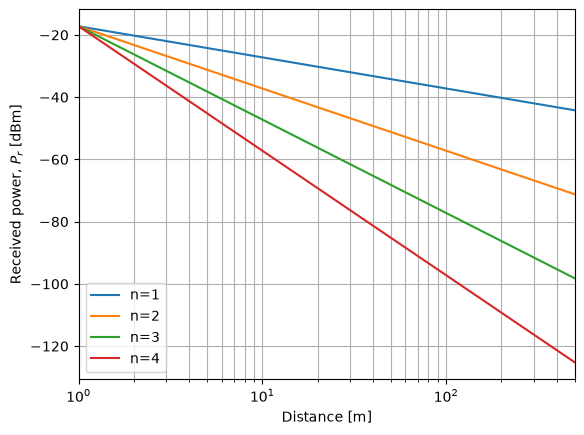

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# Goldsmith, Wireless Communication, sec. 2.6
def rx_power_dB(distance, freq, loss_exponent=2, tx_power=14):
    K = 147.55 - 20 * np.log10(freq)
    return tx_power + K - 10 * loss_exponent * np.log10(distance)

distances = np.linspace(1, 500, 1000)
path_loss = rx_power_dB(distances, FREQUENCY)


for n in [1, 2, 3, 4]:
    path_loss = rx_power_dB(distances, FREQUENCY, n)
    plt.semilogx(distances, path_loss, label=f"n={n}")
plt.xlabel("Distance [m]")
plt.ylabel("Received power, $P_r$ [dBm]")
plt.grid(True, which="both")
plt.legend()
plt.xlim(min(distances), max(distances))
plt.show()

## Path loss from attenuation factor
Complex propagation constant for general lossy material $\gamma = \alpha + j\beta=j\omega\sqrt{\mu\epsilon}$ - (Pozar Table 1.1).

Attenuation factors: 0.08 dB/m 0.11 dB/m 0.14 dB/m 

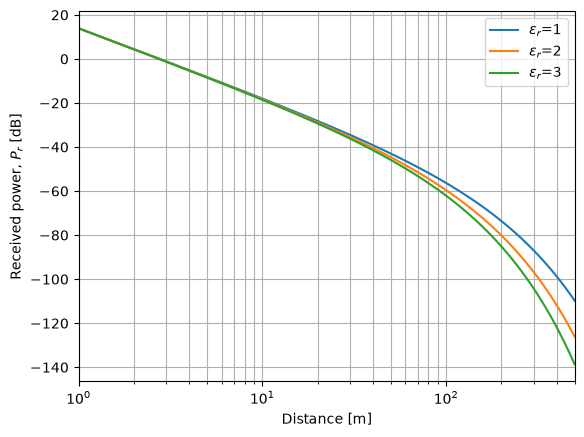

In [5]:
mu_vacuum = 4 * np.pi * 1e-7
mu = mu_vacuum
delta = 1e-3 # Tangent loss
omega = 2 * np.pi * FREQUENCY
epsilon_vaccum = 1/(36*np.pi) * 1e-9
epsilon_insulation = np.array([1, 2, 3]) 
epsilon_complex = epsilon_vaccum * epsilon_insulation * (1 - 1j * np.tan(delta))

gamma_Np = 1j * omega * np.sqrt(mu * epsilon_complex)
gamma_dB = 20/np.log(10) * gamma_Np
alpha_dB = gamma_dB.real
print("Attenuation factors:", end=" ")
for val in alpha_dB:
    print(f"{val:.2f} dB/m", end=" ")

def rx_power_dB(distance, freq, alpha, tx_power=14):
    K = 147.55 - 20 * np.log10(freq)
    return tx_power + K * np.log10(distance) - alpha * distance

for alpha, epsilon in zip(alpha_dB, epsilon_insulation):
    path_loss = rx_power_dB(distances, FREQUENCY, alpha)
    plt.semilogx(distances, path_loss, label=f"$\\epsilon_r$={epsilon}")
plt.xlabel("Distance [m]")
plt.ylabel("Received power, $P_r$ [dB]")
plt.grid(True, which="both")
plt.legend()
plt.xlim(min(distances), max(distances))
plt.show()

## Max Range for LoRa and GFSK

LoRa
Link budget 107.00 dBm
Max range: 165.68 m, no. neighbors: 13

FSK
Link budget 91.00 dBm
Max range: 103.02 m, no. neighbors: 8


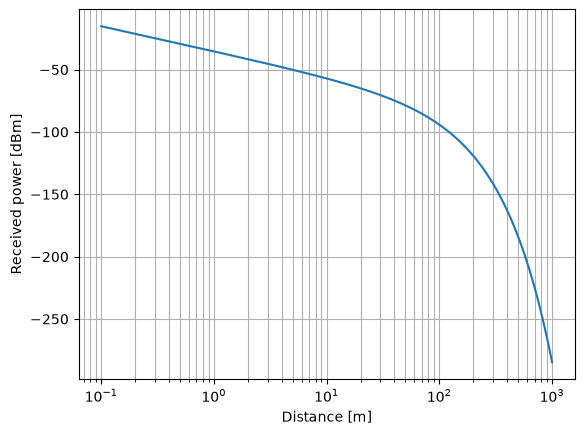

In [1]:
import sys
from pathlib import Path

sys.path.append(r"C:\Users\Christian\Desktop\lora_energysim_repos\district-heating-multihop-sim\framework")
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

from config.loader import load_config
from propagation_models import LogDistance, MaterialAttenuation

config = load_config(Path(r"C:\Users\Christian\Desktop\lora_energysim_repos\district-heating-multihop-sim\configuration.yml"))

log_distance = LogDistance(config.radio)
alpha = MaterialAttenuation(config.radio, config.u2u)

# SF6@500kHz BW with P_t=-4 dBm
link_budget = config.radio.tx_power - config.radio.rx_sensitivity
f = lambda d: log_distance(d) + alpha(d) - link_budget
max_dist = optimize.root_scalar(f, bracket=[0.1, 1500]).root
print("LoRa")
print(f"Link budget {link_budget:.2f} dBm")
print(f"Max range: {max_dist:.2f} m, no. neighbors: {int(max_dist // 12)}")

# FSK@62.5kHz BW
P_tx = -1.0 # dBm
sensitivity = -92
link_budget = P_tx - sensitivity
f = lambda d: log_distance(d) + alpha(d) - link_budget
max_dist = optimize.root_scalar(f, bracket=[0.1, 1500]).root
print("\nFSK")
print(f"Link budget {link_budget:.2f} dBm")
print(f"Max range: {max_dist:.2f} m, no. neighbors: {int(max_dist // 12)}")

# Plot received power
rx_power = lambda d: config.radio.tx_power - log_distance(d) - alpha(d)
distances = np.linspace(0.1, 1000, 1000)
plt.semilogx(distances, rx_power(distances))
plt.xlabel("Distance [m]")
plt.ylabel("Received power [dBm]")
plt.grid(True, which="both")
plt.show()


## Energy LoRa vs GFSK

In [34]:

%reload_ext autoreload
%autoreload 2
from config.models import Mac, Packet

mac = Mac(1.0)
_VCC = 3.3
_SF = 6
_BW = 500.0e3
_RX_CURRENT = 12.6e-3 # Band 1!
_CAD_PROCESS = 8.3e-3
_TX_CURRENT = 20e-3 # For 7 dBm, unknown at -4 dBm

pkt = Packet(n_preamble=8)
pkt_toa = mac.calculate_packet_toa(pkt, _SF, _BW)

t_cad, t_process = mac.calculate_cad_timings(_SF, _BW)
E_tx_lora = pkt_toa * _TX_CURRENT * _VCC
E_rx_lora = pkt_toa * _RX_CURRENT * _VCC
E_cad = (t_cad * _RX_CURRENT + t_process * _CAD_PROCESS) * _VCC
print(f"LoRa ToA {pkt_toa*1e3:.2f} ms")

print(f"LoRa TX {E_tx_lora*1e3:.4f} mJ")  
print(f"LoRa RX {E_rx_lora*1e3:.4f} mJ")
print(f"CAD {E_cad*1e6:.4f} μJ")



LoRa ToA 2.98 ms
LoRa TX 0.1964 mJ
LoRa RX 0.1237 mJ
CAD 13.9935 μJ


In [ ]:
_RX_CURRENT = 10.8e-3
_TX_CURRENT = 20e-3  # For 7 dBm, unknown at -1 dBm


def fsk_toa(
    payload_bytes,
    bitrate=50_000, # 1.2 kbps to 300 kpbs
    preamble_bytes=100,
    sync_bytes=3,
    crc_bytes=2,
    length_byte=True,
):
    overhead_bytes = [preamble_bytes, sync_bytes, crc_bytes, length_byte]
    total_bytes = payload_bytes + sum(overhead_bytes)
   
    return (total_bytes * 8) / bitrate


def fsk_energy_per_byte(payload_bytes, tx_current, vcc, **kwargs):

    toa = fsk_toa(payload_bytes, **kwargs)
    return (tx_current * toa * vcc) / payload_bytes


_N_PAYLOAD = 2 # min. no of bytes
toa = fsk_toa(_N_PAYLOAD)
E_tx_fsk = (_TX_CURRENT * toa * _VCC) / _N_PAYLOAD 
E_rx_fsk = toa * _RX_CURRENT * _VCC



print(f"FSK 50kb TX {E_tx_fsk * 1e6:.2f} μJ/byte")
print(f"FSK 50kb RX {E_rx_fsk * 1e6:.2f} μJ")

FSK 50kb TX 570.24 μJ/byte
FSK 50kb RX 615.86 μJ
